<a href="https://colab.research.google.com/github/josegabriel2007/AM_E-commerce/blob/main/Projeto_Final_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final — Aprendizado de Máquina
## E-commerce: previsão de marca (Brand) a partir do histórico de compras

**Integrantes:**
- Isaac Nascimento Santana
- Isaias Nascimento Santana
- José Gabriel dos Santos Silva

**Fonte dos dados:** https://www.kaggle.com/datasets/ayushparwal2026/online-ecommerce

**Objetivo:** usando um dataset de um e-commerce, o objetivo é identificar qual marca (`Brand`) um cliente tem maior probabilidade de comprar, dado o estado de origem e o padrão de precificação/volume da compra. Essa informação pode ser usada para direcionar campanhas de marketing por região.

**Atributo-alvo:** `Brand` (marca) — 11 categorias: Samsung, Dell, Intel, Nvidia, Hynix, Asus, Gigabyte, Western Digital, Seagate, MSI, Acer.

**Atributos preditivos:** `State_Code`, `Cost`, `Sales`, `Quantity`.

**Tipo da tarefa:** classificação (multiclasse — o atributo-alvo é categórico, com 11 categorias possíveis).


## Bibliotecas e dados

Vamos usar `pandas` e `numpy` para manipulação dos dados, `matplotlib` e `seaborn` para visualização, e `scikit-learn` para pré-processamento, treinamento e avaliação dos modelos.

Os dados são carregados diretamente do repositório do GitHub do grupo, para que o notebook funcione no Google Colab sem depender de arquivos locais.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


In [4]:
# IMPORTANTE: troquem esta URL pelo link "raw" do e-commerce.csv no repositório
# do GitHub do grupo, depois de subir o arquivo.
# Exemplo de como fica um link raw:
# https://raw.githubusercontent.com/usuario/repositorio/main/e-commerce.csv
URL_DADOS = "https://raw.githubusercontent.com/josegabriel2007/AM_E-commerce/refs/heads/main/e-commerce.csv"

df_dataset = pd.read_csv(URL_DADOS, sep=',', index_col=None)
print('Dados importados com sucesso!')
print(f'Formato original: {df_dataset.shape[0]} linhas e {df_dataset.shape[1]} colunas.')

Dados importados com sucesso!
Formato original: 5110 linhas e 14 colunas.


## 5.2 Compreensão dos dados

In [5]:
display(df_dataset.head(n=10))

,Order_Number,State_Code,Customer_Name,Order_Date,Status,Product,Category,Brand,Cost,Sales,Quantity,Total_Cost,Total_Sales,Assigned Supervisor
0,139374.0,AP,Adhir Samal,11/01/2020,Delivered,512 GB M.2,SSD,Samsung,6500.0,8450.0,1.0,6500.0,8450.0,Ajay Sharma
1,139375.0,AP,Dannana Jhammi,11/01/2020,Delivered,RYZEN 3rd gen. 3500,CPU,Intel,8500.0,11050.0,3.0,25500.0,33150.0,Roshan Kumar
2,139376.0,AS,Vipin Kumar,11/01/2020,Delivered,2GB Graphic Card,Graphic Card,Nvidia,7000.0,9100.0,2.0,14000.0,18200.0,Aarvi Gupta
3,139377.0,BR,Ranjeet Kumar,11/01/2020,Delivered,16 GB DDR4 RAM,RAM,Hynix,6550.0,8515.0,3.0,19650.0,25545.0,Vijay Singh
4,139378.0,CG,Sajal Singhal,11/01/2020,Order,Standard ATX motherboard,MotherBoard,Gigabyte,7650.0,9945.0,4.0,30600.0,39780.0,Aadil Khan
5,139379.0,CG,Akhilesh Kumar,11/01/2020,Order,Compact with 1 Fan,Cabinet,Asus,1150.0,1495.0,2.0,2300.0,2990.0,Advika Joshi
6,139380.0,CG,Suvankar Chakraborty,11/01/2020,Order,USB Backlight Keyboard,Keyboard,Dell,850.0,1105.0,3.0,2550.0,3315.0,Ajay Sharma
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,139381.0,CG,Suvankar Adhikary,12/01/2020,Order,Ergonomic Mouse,Mouse,Samsung,650.0,845.0,2.0,1300.0,1690.0,Ajay Sharma


A base de dados contém dados de venda de um e-commerce, representados pelos seguintes atributos (colunas): `Order_Number`, `State_Code`, `Customer_Name`, `Order_Date`, `Status`, `Product`, `Category`, `Brand`, `Cost`, `Sales`, `Quantity`, `Total_Cost`, `Total_Sales` e `Assigned Supervisor`.

O atributo `Order_Number` é qualitativo: apesar de ter valores numéricos crescentes, ele só identifica a amostra e poderia ser substituído por qualquer outro identificador sem prejuízo. Os atributos `State_Code`, `Customer_Name`, `Status`, `Product`, `Category`, `Brand` e `Assigned Supervisor` são qualitativos nominais. Os atributos `Cost`, `Sales`, `Quantity`, `Total_Cost` e `Total_Sales` são quantitativos.

### Estatísticas descritivas

In [6]:
print("Quantidade de registros e atributos:", df_dataset.shape)
print()
print("Tipos das variáveis:")
print(df_dataset.dtypes)
print()
display(df_dataset.describe())

Quantidade de registros e atributos: (5110, 14)

Tipos das variáveis:
Order_Number           float64
State_Code              object
Customer_Name           object
Order_Date              object
Status                  object
Product                 object
Category                object
Brand                   object
Cost                   float64
Sales                  float64
Quantity               float64
Total_Cost             float64
Total_Sales            float64
Assigned Supervisor     object
dtype: object



,Order_Number,Cost,Sales,Quantity,Total_Cost,Total_Sales
count,5095.000000,5095.000000,5095.000000,5095.000000,5095.000000,5095.000000
mean,141921.000000,6066.123651,7885.960746,2.486948,14991.778214,19489.311678
std,1470.944141,3952.022039,5137.628651,1.113581,12574.918427,16347.393955
min,139374.000000,350.000000,455.000000,1.000000,350.000000,455.000000
25%,140647.500000,2100.000000,2730.000000,2.000000,4500.000000,5850.000000
50%,141921.000000,6550.000000,8515.000000,2.000000,10720.000000,13936.000000
75%,143194.500000,8500.000000,11050.000000,3.000000,22950.000000,29835.000000
max,144468.000000,14500.000000,18850.000000,4.000000,58000.000000,75400.000000


O `count` mostra quantas linhas têm valor preenchido em cada coluna quantitativa — já dá uma pista de quantas amostras têm dado ausente (compare com o total de linhas). `mean` e `std` mostram que `Cost` e `Sales` têm médias e desvios-padrão numa faixa proporcional entre si, o que já sugere a forte correlação que vamos confirmar mais adiante. `Quantity` varia numa faixa bem mais estreita (poucas unidades por pedido).

### Valores ausentes

In [7]:
print("Valores ausentes por coluna:")
display(df_dataset.isnull().sum())

idxRowNan = pd.isnull(df_dataset).any(axis=1).to_numpy().nonzero()[0]
print(f"\nTotal de amostras (linhas) com algum valor ausente: {len(idxRowNan)}")

Valores ausentes por coluna:


,0
Order_Number,15
State_Code,15
Customer_Name,15
Order_Date,15
Status,15
Product,15
Category,15
Brand,15
Cost,15
Sales,15



Total de amostras (linhas) com algum valor ausente: 15


Todas as colunas têm exatamente o mesmo número de valores ausentes, e são **as mesmas linhas** em todos os casos — ou seja, não é um problema de um atributo específico falhando, são registros de pedido completamente vazios (provavelmente linhas em branco inseridas por engano na exportação da planilha). Como essas linhas não têm nenhuma informação aproveitável (nem o próprio alvo `Brand`), a imputação não faz sentido: a decisão é remover essas linhas com `dropna()`.

In [8]:
df_dataset = df_dataset.dropna()
print("Verificação de valores ausentes APÓS a limpeza:")
display(df_dataset.isnull().sum())
print(f"\nLinhas restantes: {df_dataset.shape[0]}")

Verificação de valores ausentes APÓS a limpeza:


,0
Order_Number,0
State_Code,0
Customer_Name,0
Order_Date,0
Status,0
Product,0
Category,0
Brand,0
Cost,0
Sales,0



Linhas restantes: 5095


### Duplicações — atenção à ordem das operações

Uma primeira tentativa natural seria remover colunas irrelevantes (como `Customer_Name`, `Order_Date`, `Product`) e **depois** checar duplicatas. Isso é um erro sutil aqui: depois de remover essas colunas, sobram poucos atributos (`State_Code`, `Brand`, `Cost`, `Sales`, `Quantity`), com poucos valores possíveis — várias transações **diferentes** (clientes e datas diferentes) acabam tendo a mesma combinação desses 5 valores só por coincidência, e seriam apagadas como se fossem duplicatas, destruindo boa parte da base sem necessidade.

A forma correta é checar duplicação usando a linha inteira, com exceção do `Order_Number` (que é só um identificador sequencial e nunca se repete por definição):

In [9]:
duplicatas = df_dataset.drop(columns=['Order_Number']).duplicated().sum()
print(f"Transações duplicadas de fato (linha inteira, exceto Order_Number): {duplicatas}")

Transações duplicadas de fato (linha inteira, exceto Order_Number): 0


Não há nenhuma transação duplicada de verdade — cada pedido é único. Portanto, **não vamos aplicar `drop_duplicates()`** neste dataset: fazer isso depois de remover as colunas de identificação removeria dados legítimos, prejudicando principalmente as marcas com menos amostras (Acer, Seagate, MSI).

### Distribuição do atributo-alvo e desbalanceamento

,count
Brand,
Samsung,1199
Dell,898
Intel,600
Nvidia,450
Hynix,450
Asus,449
Gigabyte,300
Western Digital,299
Seagate,150


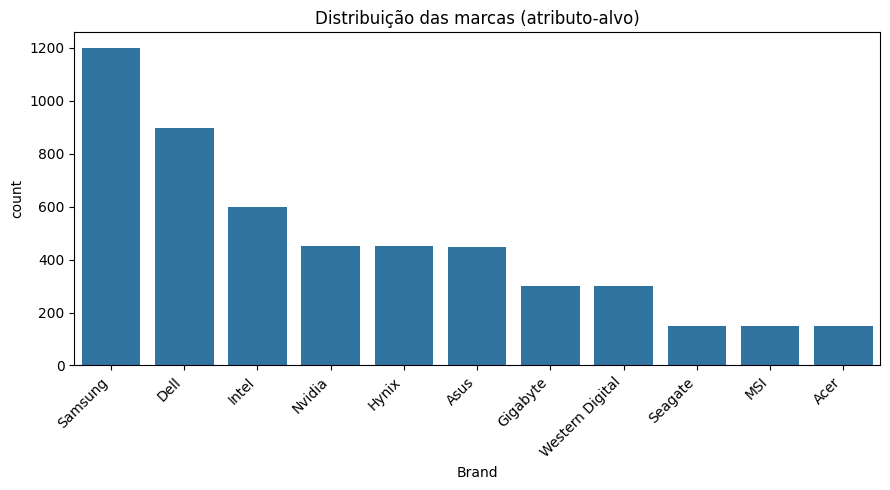

In [10]:
display(df_dataset['Brand'].value_counts())

plt.figure(figsize=(9,5))
sns.countplot(x="Brand", data=df_dataset, order=df_dataset['Brand'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Distribuição das marcas (atributo-alvo)")
plt.tight_layout()
plt.show()

As marcas estão claramente desbalanceadas: `Samsung` e `Dell` dominam a base, enquanto `Acer`, `Seagate` e `MSI` têm bem menos amostras — quase 8 vezes menos que a Samsung. Isso importa porque a maioria dos algoritmos de classificação tende a favorecer as classes majoritárias durante o treinamento. Vamos tratar isso na seção 5.4/5.6, usando `class_weight='balanced'` no `RandomForestClassifier`, que penaliza mais os erros nas classes minoritárias em vez de reamostrar os dados artificialmente.

## 5.3 Análise exploratória

### Eliminação de atributos irrelevantes

Antes de explorar as relações entre os atributos, vamos remover do conjunto de trabalho as colunas que não ajudam (e podem até atrapalhar) a análise e o treinamento: `Order_Number`, `Customer_Name`, `Order_Date`, `Status` e `Assigned Supervisor` são apenas identificadores/metadados administrativos, sem relação com o padrão de compra. `Total_Cost` e `Total_Sales` são combinações lineares de `Cost`/`Sales` com `Quantity` — mantê-los seria redundante.

Também removemos `Product` e `Category`: seus valores são altamente específicos por marca (ex.: um determinado modelo de processador só existe associado a um fabricante específico), então o modelo aprenderia a simplesmente "decorar" o nome do produto em vez de aprender o padrão real de precificação, volume e região — um caso clássico de vazamento de informação (*data leakage*) por atributo proxy do alvo. Removendo essas colunas, forçamos o modelo a classificar a marca usando só `State_Code`, `Cost`, `Sales` e `Quantity` — justamente o cenário de negócio que queremos resolver (prever a marca **sem** conhecer o produto exato).

In [11]:
df_dataset = df_dataset.drop(columns=['Order_Number', 'Customer_Name', 'Order_Date',
                                       'Status', 'Product', 'Assigned Supervisor',
                                       'Category', 'Total_Cost', 'Total_Sales'])

colunas_quantitativas = ['Cost', 'Sales', 'Quantity']

display(df_dataset.head(n=10))

,State_Code,Brand,Cost,Sales,Quantity
0,AP,Samsung,6500.0,8450.0,1.0
1,AP,Intel,8500.0,11050.0,3.0
2,AS,Nvidia,7000.0,9100.0,2.0
3,BR,Hynix,6550.0,8515.0,3.0
4,CG,Gigabyte,7650.0,9945.0,4.0
5,CG,Asus,1150.0,1495.0,2.0
6,CG,Dell,850.0,1105.0,3.0
9,CG,Samsung,650.0,845.0,2.0
10,CG,Dell,7500.0,9750.0,1.0
11,JK,Seagate,10000.0,13000.0,3.0


### Concentração geográfica por marca

Uma tabela cruzada entre `State_Code` e `Brand` ajuda a avaliar se há concentração de alguma marca em algum estado específico — o que impacta diretamente a capacidade do modelo de generalizar.

In [12]:
tabela_demanda = df_dataset.groupby(['State_Code', 'Brand']).size().unstack(fill_value=0)
display(tabela_demanda)

Brand,Acer,Asus,Dell,Gigabyte,Hynix,Intel,MSI,Nvidia,Samsung,Seagate,Western Digital
State_Code,,,,,,,,,,,
AN,0,3,6,2,2,3,0,1,3,2,2
AP,3,9,15,4,7,12,2,7,23,2,4
AR,2,6,18,6,8,11,2,6,20,2,6
AS,4,8,14,6,6,9,2,8,21,3,5
BR,8,20,49,11,21,33,8,21,60,7,16
CG,2,7,17,6,7,9,2,8,21,3,6
CH,2,8,16,6,8,10,2,9,25,3,6
DD,3,7,17,5,7,10,3,9,18,2,5
DH,2,9,15,5,9,12,3,8,22,3,3


A marca com maior número de vendas registradas é a Samsung, e os estados com mais compras registradas são MH, GJ e UP — os mesmos que já apareciam na contagem geral de `State_Code`.

### Histogramas

Histogramas ajudam a detectar *outliers* nos atributos quantitativos.

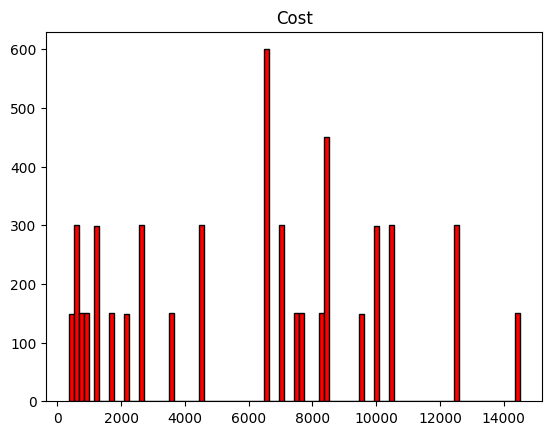

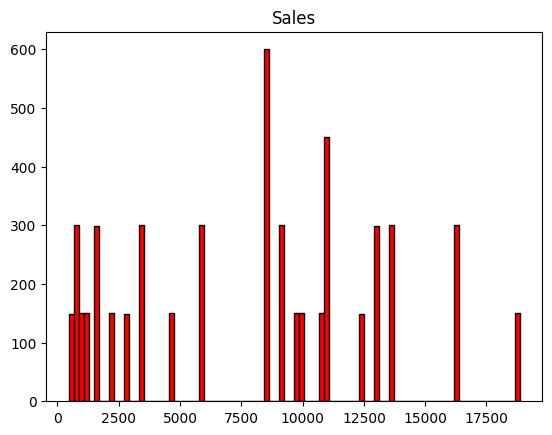

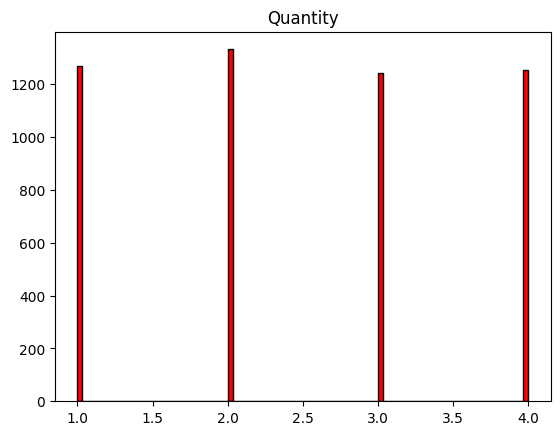

In [13]:
for atributo in colunas_quantitativas:
    plt.figure()
    plt.hist(df_dataset[atributo].values, bins=90, color='red', edgecolor='black', linewidth=1)
    plt.title(atributo)
    plt.show()

Os histogramas de `Cost` e `Sales` mostram uma distribuição com múltiplos picos (multimodal), sem uma cauda longa isolada — ou seja, não há indícios de outliers extremos, apenas diferentes "faixas de preço" que provavelmente correspondem a diferentes marcas/categorias de produto. `Quantity` concentra-se em poucos valores discretos, sem valores anômalos.

### Gráficos de densidade

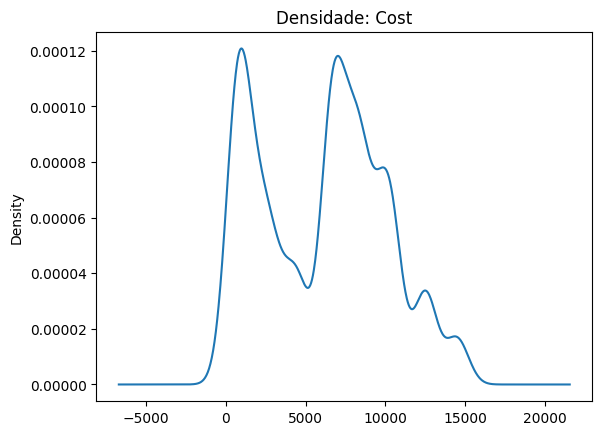

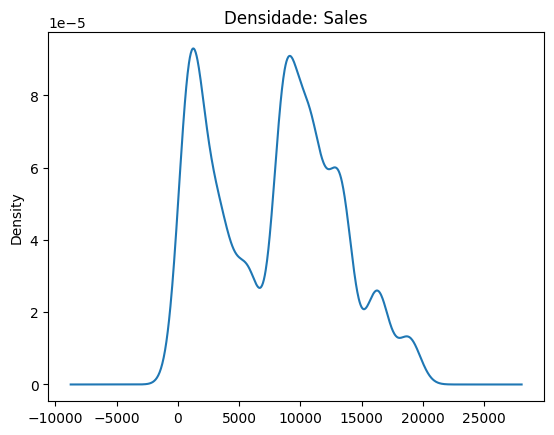

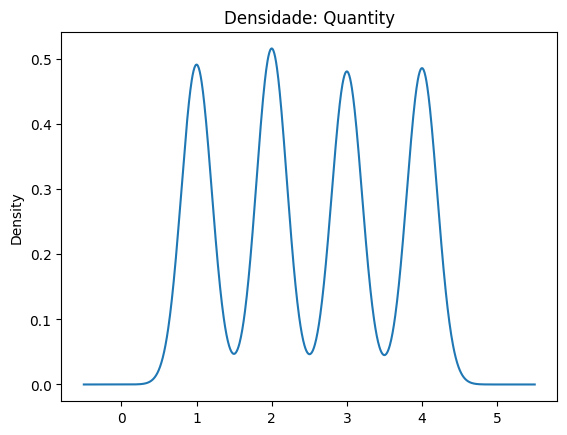

In [14]:
for atributo in colunas_quantitativas:
    df_dataset[atributo].plot(kind='density')
    plt.title(f"Densidade: {atributo}")
    plt.show()

Os gráficos de `Cost` e `Sales` têm o mesmo formato (picos nas mesmas posições relativas), o que já indica a forte correlação entre essas duas variáveis. O primeiro pico à esquerda representa maior volume de transações com produtos mais baratos; a "cauda" à direita representa os produtos mais caros, mas — como vimos no histograma — sem valores destoantes o bastante para serem considerados outliers. Em `Quantity`, os picos de altura parecida mostram que comprar diferentes quantidades por pedido tem probabilidade parecida.

### Boxplot geral (escala padronizada, apenas para visualização)

Para comparar a dispersão das três variáveis quantitativas num único gráfico, precisamos colocá-las na mesma escala — senão `Cost`/`Sales` (na casa dos milhares) dominam visualmente o `Quantity` (poucas unidades). Por isso, criamos aqui uma cópia **temporária e apenas para visualização** dos dados padronizados (Z-score), calculada sobre a base inteira nesta etapa de análise exploratória. Essa cópia não será reaproveitada no treinamento dos modelos — lá (seção 5.5), a padronização será recalculada corretamente usando somente o conjunto de treino, para não vazar informação do teste.

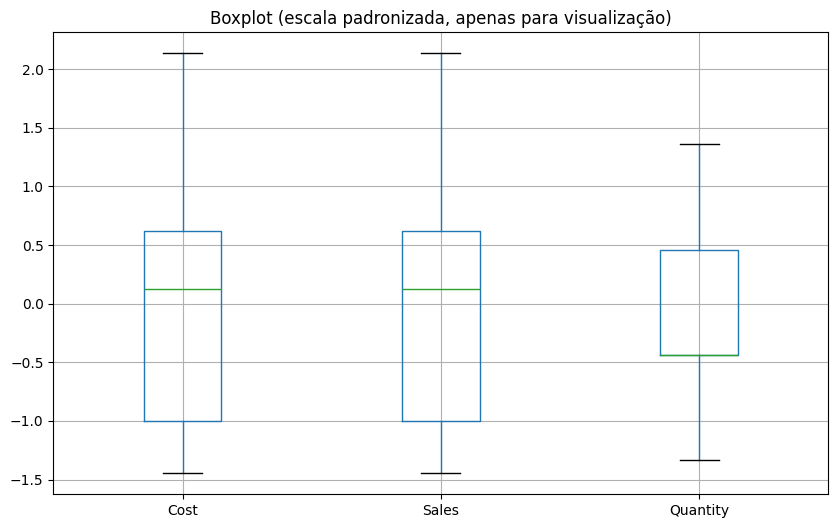

In [15]:
from sklearn.preprocessing import StandardScaler

df_visualizacao = df_dataset.copy()
df_visualizacao[colunas_quantitativas] = StandardScaler().fit_transform(df_visualizacao[colunas_quantitativas])

df_visualizacao[colunas_quantitativas].boxplot(figsize=(10,6))
plt.title("Boxplot (escala padronizada, apenas para visualização)")
plt.show()

O boxplot mostra homogeneidade na distribuição de `Cost`, `Sales` e `Quantity`, sem pontos marcados como outliers fora dos limites (whiskers) — reforçando o que já havíamos observado nos histogramas: a base é estruturalmente consistente e não tem anomalias relevantes nessas três variáveis.

### Gráficos de dispersão

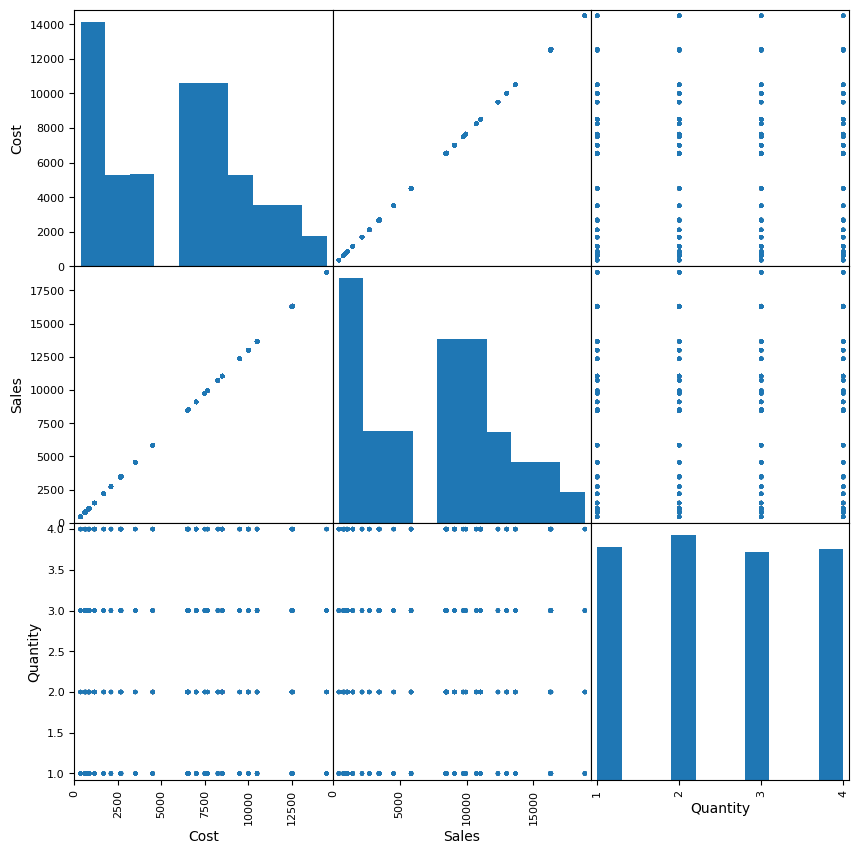

In [16]:
pd.plotting.scatter_matrix(df_dataset[colunas_quantitativas], figsize=(10,10))
plt.show()

A relação entre `Cost` e `Sales` é fortemente linear e crescente — confirma que existe uma margem de lucro proporcional aplicada de forma consistente (quanto maior o custo, maior a venda, na mesma proporção). Já `Quantity` não mostra nenhuma tendência clara com `Cost` ou `Sales`: a disposição do cliente em comprar mais ou menos itens parece independente do preço do produto.

Incluindo a marca como cor no gráfico de dispersão, conseguimos ver se esses padrões mudam entre marcas.

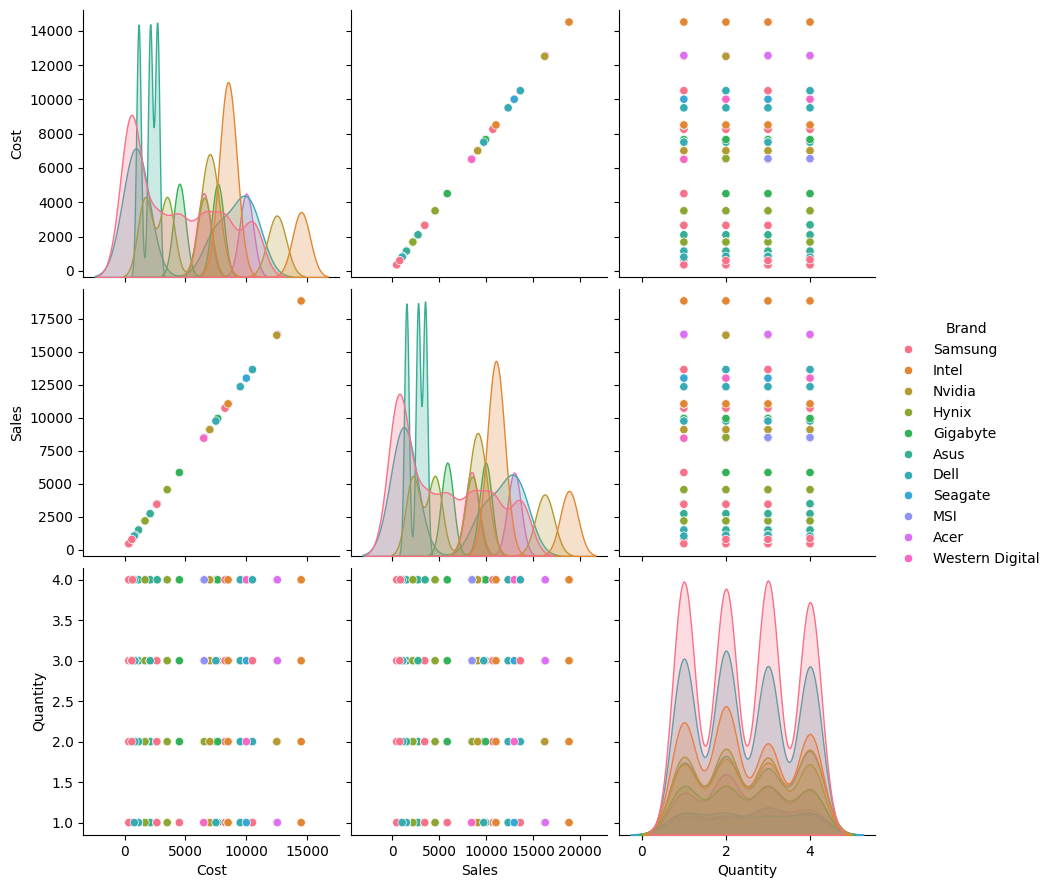

In [17]:
sns.pairplot(df_dataset, hue='Brand', vars=colunas_quantitativas, height=3)
plt.show()

A relação linear entre `Cost` e `Sales` se mantém em todas as marcas — a política de margem de lucro é padronizada, não há uma marca com margem diferenciada. As marcas de maior valor (outliers superiores de preço) são Intel e Nvidia; Samsung concentra-se nas faixas de menor custo, mas domina o volume de transações — a "base de giro rápido" do catálogo.

### Boxplots por marca

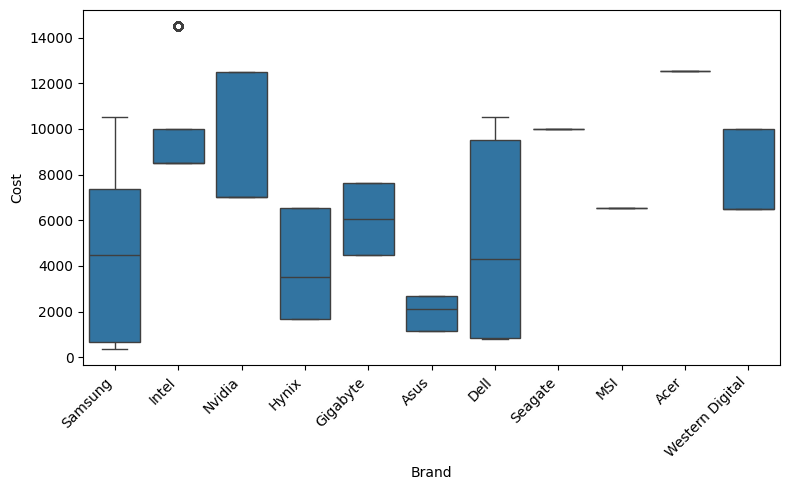

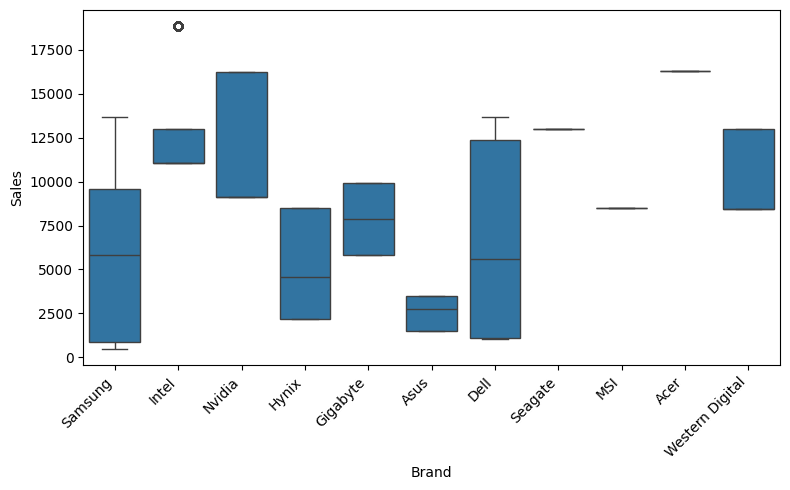

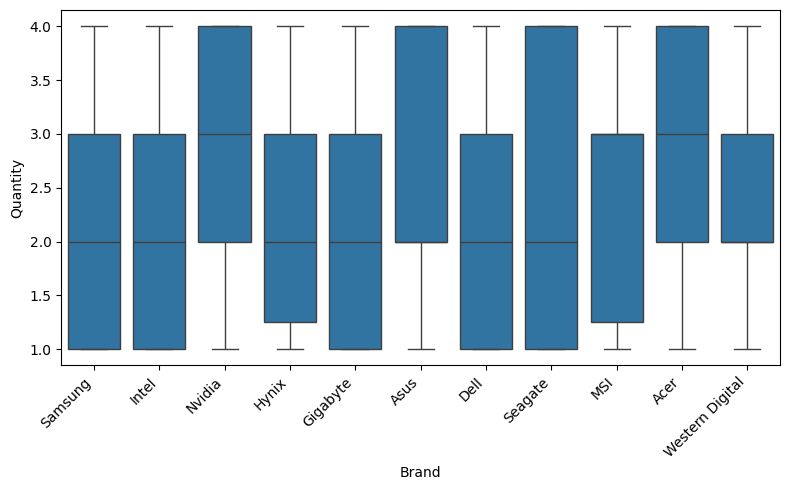

In [18]:
for atributo in colunas_quantitativas:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Brand", y=atributo, data=df_dataset, whis=1.5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Nos gráficos de `Cost` e `Sales`, as distribuições têm o mesmo formato por marca, confirmando a margem de lucro padronizada. As marcas se dividem em dois grupos de faixa de preço: Samsung, Asus e Hynix (menor valor agregado) vs. Intel e Nvidia (posicionadas como marcas premium). Acer, Seagate e MSI têm variância de preço quase nula — catálogo restrito ou faixa de preço fixa. Em `Quantity`, há mais dispersão entre marcas: Acer, Seagate e MSI, apesar da pouca variação de preço, têm volumes de compra variados, sugerindo que consumidores dessas marcas costumam levar múltiplas unidades por pedido.

### Correlação entre atributos

,Cost,Sales,Quantity
Cost,1.000000,1.000000,-0.021444
Sales,1.000000,1.000000,-0.021444
Quantity,-0.021444,-0.021444,1.000000


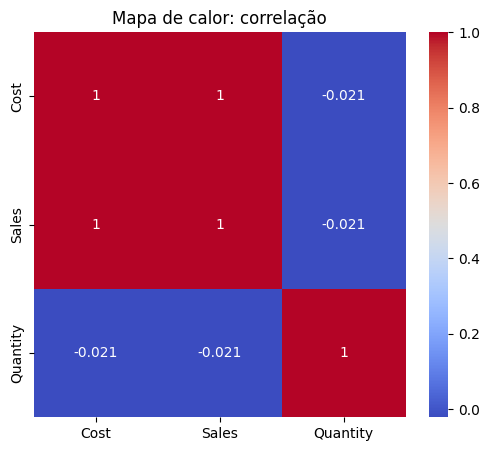

In [19]:
df_correlation = df_dataset[colunas_quantitativas].corr()
display(df_correlation)

plt.figure(figsize=(6,5))
sns.heatmap(df_correlation, annot=True, cmap='coolwarm')
plt.title('Mapa de calor: correlação')
plt.show()

`Cost` e `Sales` têm correlação praticamente igual a 1 — são redundantes do ponto de vista estatístico. Como a base já tem poucos atributos contínuos, optamos por manter os dois nesta primeira rodada de testes (preservar o contexto financeiro completo).

## 5.4 Pré-processamento

Resumo dos tratamentos aplicados até aqui e dos que faltam, seguindo o padrão *problema → tratamento → justificativa* pedido no enunciado:

| Problema encontrado | Tratamento aplicado | Justificativa |
|---|---|---|
| Linhas totalmente vazias | `dropna()` | Sem nenhum valor preenchido (nem o alvo), imputação não é viável |
| Colunas administrativas/identificadoras (`Order_Number`, `Customer_Name`, `Order_Date`, `Status`, `Assigned Supervisor`) | Remoção | Não têm relação com o padrão de compra |
| `Total_Cost`/`Total_Sales` | Remoção | Combinações lineares de `Cost`/`Sales` × `Quantity`; redundantes |
| `Product`/`Category` | Remoção | Vazamento de informação (proxy quase direto da marca) |
| Duplicação aparente ao usar poucas colunas | Verificação feita sobre a linha inteira (exceto `Order_Number`) | Confirmado: 0 duplicatas reais — nenhuma remoção necessária |
| `State_Code` é categórico nominal | *One-hot encoding* (`pd.get_dummies`) | Evita impor uma ordem numérica artificial entre estados |
| `Brand` (alvo) é categórico | `LabelEncoder` | Simples de reverter para os nomes das marcas na hora de interpretar os resultados |
| `Cost`/`Sales`/`Quantity` em escalas muito diferentes | Padronização (Z-score) | Necessária para o `SGDClassifier`, que é sensível à escala das variáveis |
| Marcas desbalanceadas (Samsung/Dell dominantes) | `class_weight='balanced'` no `RandomForestClassifier` | Penaliza mais os erros nas classes minoritárias, sem descartar ou duplicar dados |

Duas dessas etapas — a padronização e, por consequência, o treinamento dos modelos — só podem ser feitas com segurança **depois** de separar treino e teste (seção 5.5): se calculássemos a média e o desvio-padrão usando a base inteira, o conjunto de teste "vazaria" informação estatística para o treino. Por isso, codificamos as variáveis categóricas agora (não depende de nenhuma estatística da base), mas deixamos a padronização para logo após o `train_test_split`.

### Codificação das variáveis categóricas

In [20]:
from sklearn.preprocessing import LabelEncoder

df_preparado = pd.get_dummies(df_dataset, columns=['State_Code'], dtype=int)

codificador_alvo = LabelEncoder()
df_preparado['Brand'] = codificador_alvo.fit_transform(df_preparado['Brand'])

print("Classes do alvo (ordem usada pelo LabelEncoder):")
print(list(enumerate(codificador_alvo.classes_)))

display(df_preparado.head())

Classes do alvo (ordem usada pelo LabelEncoder):
[(0, 'Acer'), (1, 'Asus'), (2, 'Dell'), (3, 'Gigabyte'), (4, 'Hynix'), (5, 'Intel'), (6, 'MSI'), (7, 'Nvidia'), (8, 'Samsung'), (9, 'Seagate'), (10, 'Western Digital')]


,Brand,Cost,Sales,Quantity,State_Code_AN,State_Code_AP,State_Code_AR,State_Code_AS,State_Code_BR,State_Code_CG,State_Code_CH,State_Code_DD,State_Code_DH,State_Code_DL,State_Code_GA,State_Code_GJ,State_Code_HP,State_Code_HR,State_Code_JH,State_Code_JK,State_Code_KA,State_Code_KL,State_Code_LD,State_Code_MH,State_Code_ML,State_Code_MN,State_Code_MP,State_Code_MZ,State_Code_NL,State_Code_OR,State_Code_PB,State_Code_PY,State_Code_RJ,State_Code_SK,State_Code_TN,State_Code_TR,State_Code_UK,State_Code_UP,State_Code_WB
0,8,6500.0,8450.0,1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,5,8500.0,11050.0,3.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,7,7000.0,9100.0,2.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,6550.0,8515.0,3.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,3,7650.0,9945.0,4.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
X = df_preparado.drop(columns=['Brand'])
y = df_preparado['Brand']

print("X:", X.shape, " | y:", y.shape)

X: (5095, 38)  | y: (5095,)


## 5.5 Separação dos dados

Separamos 80% dos dados para treino e 20% para teste. Mesmo a menor classe (`Acer`/`Seagate`/`MSI`) fica com um número razoável de exemplos nos dois conjuntos com essa proporção. Usamos `stratify=y` para garantir que a proporção de cada marca seja preservada tanto no treino quanto no teste — essencial aqui, já que as marcas são desbalanceadas. O conjunto de teste é reservado e só será usado na avaliação final (seção 5.7); toda comparação de modelos na seção 5.6 usa validação cruzada dentro do treino.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Treino:", X_train.shape, " | Teste:", X_test.shape)
print("\nProporção de cada marca no treino:")
print((y_train.value_counts(normalize=True) * 100).round(1))

Treino: (4076, 38)  | Teste: (1019, 38)

Proporção de cada marca no treino:
Brand
8     23.5
2     17.6
5     11.8
4      8.8
7      8.8
1      8.8
3      5.9
10     5.9
6      2.9
0      2.9
9      2.9
Name: proportion, dtype: float64


### Padronização (Z-score)

Para padronizar o `Cost`, `Sales` e `Quantity` sem vazamento: o `StandardScaler` é ajustado (`fit`) **só com o treino**, e depois aplicado (`transform`, sem novo `fit`) ao teste.

In [23]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_quantitativas] = scaler.fit_transform(X_train[colunas_quantitativas])
X_test_scaled[colunas_quantitativas] = scaler.transform(X_test[colunas_quantitativas])

display(X_train_scaled.head())

,Cost,Sales,Quantity,State_Code_AN,State_Code_AP,State_Code_AR,State_Code_AS,State_Code_BR,State_Code_CG,State_Code_CH,State_Code_DD,State_Code_DH,State_Code_DL,State_Code_GA,State_Code_GJ,State_Code_HP,State_Code_HR,State_Code_JH,State_Code_JK,State_Code_KA,State_Code_KL,State_Code_LD,State_Code_MH,State_Code_ML,State_Code_MN,State_Code_MP,State_Code_MZ,State_Code_NL,State_Code_OR,State_Code_PB,State_Code_PY,State_Code_RJ,State_Code_SK,State_Code_TN,State_Code_TR,State_Code_UK,State_Code_UP,State_Code_WB
1887,0.237691,0.237691,1.365452,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4365,0.867779,0.867779,0.467343,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2179,1.119814,1.119814,-0.430766,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3069,-0.392396,-0.392396,1.365452,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1128,0.615744,0.615744,-0.430766,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 5.6 Modelagem

### Baseline

Antes de treinar modelos "de verdade", criamos um baseline com o `DummyClassifier`, que prevê seguindo apenas a distribuição das classes no treino, sem olhar para nenhum atributo preditivo. Qualquer modelo real precisa superar esse baseline por uma margem clara para justificar seu uso.

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train_scaled, y_train)

print("Acurácia do baseline (Dummy):", accuracy_score(y_test, dummy_clf.predict(X_test_scaled)))

Acurácia do baseline (Dummy): 0.13346418056918546


### SGDClassifier vs. RandomForestClassifier

O enunciado exige, para classificação, no mínimo o `SGDClassifier` e o `RandomForestClassifier`. Comparamos os dois usando validação cruzada de 5 *folds* sobre o conjunto de treino (o teste continua intocado).

In [25]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

sgd_clf = SGDClassifier(random_state=42)
scores_sgd = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=5, scoring='accuracy')

rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
scores_rf = cross_val_score(rf_clf, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"SGDClassifier          — acurácia média (CV): {scores_sgd.mean():.2%}  (desvio: {scores_sgd.std():.2%})")
print(f"RandomForestClassifier — acurácia média (CV): {scores_rf.mean():.2%}  (desvio: {scores_rf.std():.2%})")

SGDClassifier          — acurácia média (CV): 19.92%  (desvio: 4.41%)
RandomForestClassifier — acurácia média (CV): 83.00%  (desvio: 1.08%)


O `RandomForestClassifier` supera o `SGDClassifier`. O `SGDClassifier` treinado aqui é um classificador **linear** (`hinge loss`), e a fronteira entre as 11 marcas não é linear no espaço de `Cost`/`Sales`/`Quantity`/`State_Code` — marcas se distinguem por faixas de preço e combinações de estado que uma reta (ou hiperplano) não separa bem. Já o `RandomForestClassifier`, por construir várias árvores com divisões (*splits*) não-lineares, consegue capturar regras do tipo "se o custo está nessa faixa Z o estado é X, então provavelmente é a marca Y" muito mais facilmente.



### Principais hiperparâmetros do modelo final

- `n_estimators` (padrão 100): número de árvores no ensemble;
- `class_weight='balanced'`: compensa o desbalanceamento entre marcas, dando peso maior às classes minoritárias durante o treinamento;
- `random_state=42`: garante a reprodutibilidade dos resultados.

## 5.7 Avaliação e discussão

In [30]:
rf_clf.fit(X_train_scaled, y_train)
y_pred = rf_clf.predict(X_test_scaled)

print("Acurácia no conjunto de teste:", accuracy_score(y_test, y_pred))

Acurácia no conjunto de teste: 0.8213935230618253


### Matriz de confusão

A matriz de confusão mostra quais marcas o modelo mais confunde entre si.

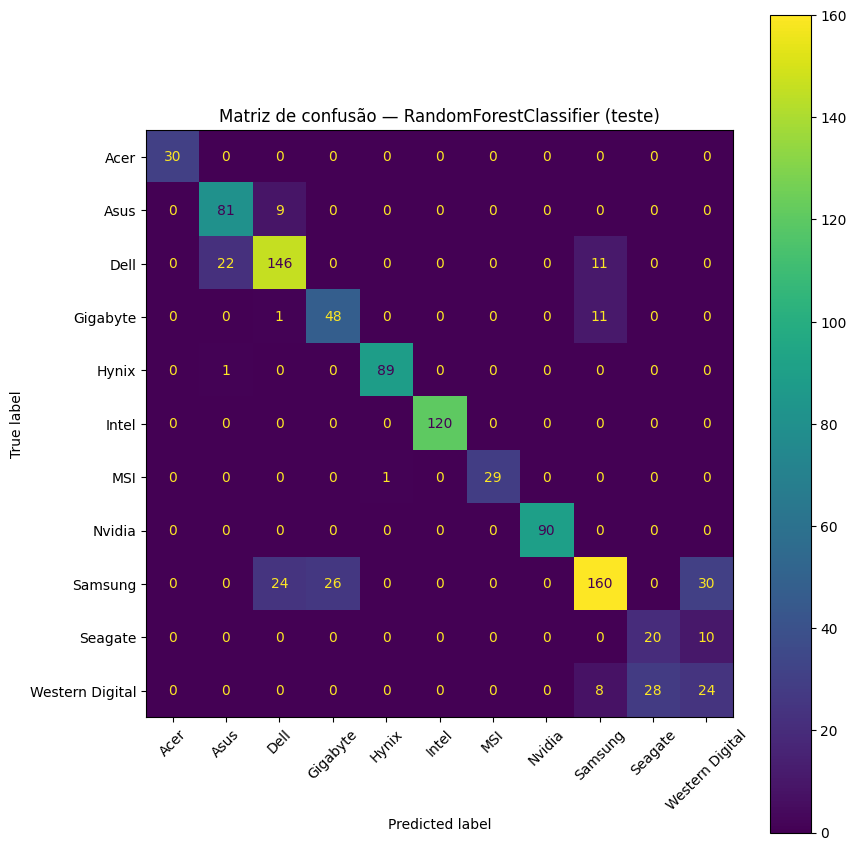

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9,9))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=codificador_alvo.classes_,
    xticks_rotation=45, ax=ax
)
plt.title("Matriz de confusão — RandomForestClassifier (teste)")
plt.tight_layout()
plt.show()

### Métricas por marca

Além da acurácia geral, é importante olhar precisão, revocação e F1 por marca — a acurácia sozinha pode esconder um desempenho ruim nas classes minoritárias.

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=codificador_alvo.classes_))

                 precision    recall  f1-score   support

           Acer       1.00      1.00      1.00        30
           Asus       0.78      0.90      0.84        90
           Dell       0.81      0.82      0.81       179
       Gigabyte       0.65      0.80      0.72        60
          Hynix       0.99      0.99      0.99        90
          Intel       1.00      1.00      1.00       120
            MSI       1.00      0.97      0.98        30
         Nvidia       1.00      1.00      1.00        90
        Samsung       0.84      0.67      0.74       240
        Seagate       0.42      0.67      0.51        30
Western Digital       0.38      0.40      0.39        60

       accuracy                           0.82      1019
      macro avg       0.81      0.84      0.82      1019
   weighted avg       0.83      0.82      0.82      1019



### Discussão dos resultados

**Qual modelo teve o melhor resultado e por quê:** o `RandomForestClassifier` teve acurácia de aproximadamente 82% no teste, muito acima do baseline (~13%) e do `SGDClassifier` (~20%). Isso confirma a limitação de um modelo linear para separar 11 marcas usando apenas preço, quantidade e estado.

**Onde o modelo erra mais:** marcas como Intel, Nvidia, Hynix, Acer e MSI são classificadas quase perfeitamente (F1 próximo de 1.0) — provavelmente porque ocupam faixas de preço bem distintas das demais. Já `Western Digital` e `Seagate` têm os piores resultados (F1 na faixa de 0.4–0.5), sendo confundidas entre si e com outras marcas — plausível, já que produtos de armazenamento de fabricantes diferentes tendem a ter faixas de preço parecidas. `Samsung`, apesar de ser a marca mais frequente, tem revocação mais baixa que precisão: o modelo é conservador ao prever "Samsung", errando ao classificar algumas amostras dessa marca como outras.

**Limitações:** o modelo usa só 4 atributos preditivos (`State_Code`, `Cost`, `Sales`, `Quantity`), sem nenhuma informação sobre o produto em si (removida de propósito para evitar vazamento) — é esperado que marcas com faixas de preço muito parecidas sejam mais difíceis de separar só pelo valor da transação. Além disso, `Cost` e `Sales` são altamente correlacionados (redundantes), então na prática o modelo tem menos informação independente do que o número de colunas sugere.

**O que poderia ser melhorado:** (1) testar outros atributos preditivos que não causem vazamento, como uma categoria de produto mais genérica (ex.: "armazenamento", "processamento") em vez do nome específico; (2) testar balanceamento por reamostragem (ex. `SMOTE`) além do `class_weight`; (3) fazer uma busca de hiperparâmetros (`GridSearchCV`) no `RandomForestClassifier`, por exemplo variando `n_estimators` e `max_depth`.